In [1]:
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import yaml
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.model_selection import train_test_split


import src.data.utils as dutils
from src.models.neural import MLPv01

In [2]:
PATH = "../data/raw/cifar-10-python.tar/cifar-10-python/cifar-10-batches-py/"
comb_df, test_df = dutils.read_data_v2(PATH)

with open("../configs/base_config.yaml", 'r') as f:
    base_config = yaml.safe_load(f)

comb_df.shape, test_df.shape

C:\Work\Project\cv-architecture-sprint-cifar\src\data\utils.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = pickle.load(fo, encoding='bytes')


((50000, 3), (10000, 3))

In [3]:
torch.manual_seed(base_config["base"]["random_state"])
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
X = comb_df["data"]; y = comb_df["label"]
X_test = test_df["data"]; y_test = test_df["label"]
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                  test_size=base_config["base"]["val_split"], 
                                                  random_state=base_config["base"]["random_state"], 
                                                  stratify=y)


print("Train size: ", X_train.shape, y_train.shape)
print("Test size: ", X_test.shape, y_test.shape)
print("Val size: ", X_val.shape, y_val.shape)

Train size:  (40000,) (40000,)
Test size:  (10000,) (10000,)
Val size:  (10000,) (10000,)


In [5]:
train_df = pl.DataFrame({"data": X_train, "label": y_train})
val_df = pl.DataFrame({"data": X_val, "label": y_val})

train_df.shape, val_df.shape

((40000, 2), (10000, 2))

In [6]:
test_df.head()

label,data,label_names
i64,"array[u8, 3072]",str
3,"[158, 159, … 110]","""cat"""
8,"[235, 231, … 199]","""ship"""
8,"[158, 158, … 7]","""ship"""
0,"[155, 167, … 50]","""airplane"""
6,"[65, 70, … 117]","""frog"""


In [7]:
train_dataset = dutils.CIFARData(train_df)
test_dataset = dutils.CIFARData(test_df)
val_dataset = dutils.CIFARData(val_df)

train_loader = DataLoader(train_dataset, 
                         batch_size=base_config["neural"]["train_batch_size"], shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, 
                       batch_size=base_config["neural"]["batch_size"], num_workers=2)
test_loader = DataLoader(test_dataset, 
                        batch_size=base_config["neural"]["batch_size"], num_workers=2)

In [8]:
train_dataset[0]

{'data': tensor([[160., 161., 161.,  ..., 168., 181., 187.]]),
 'label': tensor([9])}

In [9]:
net = MLPv01(
    input_dim= 32 * 32 * 3,
    n_classes=len(y.unique())
).to(base_config["base"]["gpu"])
optim = torch.optim.AdamW(net.parameters(), lr=1e-3, 
                          weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

In [10]:
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

history = {
    "train_loss": [],
    "val_loss": [],
    "cm": []
}

for epoch in  tqdm(range(1, base_config["neural"]["epochs"] + 1), total=base_config["neural"]["epochs"]):
    y_val_pred = []
    y_val = []
    
    train_loss = 0.0
    
    net.train()
    for step, batch in tqdm(enumerate(train_loader, 1), total=len(train_loader), desc="Training"):
        optim.zero_grad()
        
        _data = batch["data"].to(base_config["base"]["gpu"])
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        logit = net(_data.reshape((_data.shape[0], -1)))
        loss = criterion(logit, _label)
        
        loss.backward()
        optim.step()
        
        train_loss += loss
    train_loss = train_loss / len(train_loader)
    print(f"Training loss on epoch: {epoch}: {train_loss}")
    
    val_loss = 0.0
    net.eval()
    with torch.no_grad():
        for step, batch in enumerate(val_loader, 1):
            _data = batch["data"].to(base_config["base"]["gpu"])
            _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
            logit = net(_data.reshape((_data.shape[0], -1)))
            loss = criterion(logit, _label)
            
            val_loss += loss
            y_pred = logit.argmax(1)
            
            y_val.extend(_label.cpu().numpy())
            y_val_pred.extend(y_pred.cpu().numpy())
    val_loss = val_loss / len(val_loader)
    print(f"Val loss on epoch: {epoch}: {val_loss}")
    
    cm = confusion_matrix(y_val, y_val_pred)
    print(cm)
    
    history["train_loss"].append(train_loss.detach().cpu().numpy())
    history["val_loss"].append(val_loss.detach().cpu().numpy())
    history["cm"].append(cm)

Training: 100%|██████████| 1250/1250 [00:07<00:00, 173.18it/s]


Training loss on epoch: 1: 1.8116044998168945


 20%|██        | 1/5 [00:19<01:19, 19.87s/it]

Val loss on epoch: 1: 1.6754837036132812
[[386  18 203  13  31 133  33  44 116  23]
 [ 54 341  34  34  23 101  57  37 100 219]
 [ 38   6 354  43 105 203 165  57  14  15]
 [  7   4  91 128  28 507 164  37  16  18]
 [ 36   1 194  24 269 130 230  83  25   8]
 [  5   3  83  80  35 581 143  45  14  11]
 [  3   4 110  31  56 196 576  12   7   5]
 [ 30   7  84  27  76 197  83 459   8  29]
 [122  25  71  21  16 126  19  19 537  44]
 [ 80  75  25  36  16 144  51  65  72 436]]


Training: 100%|██████████| 1250/1250 [00:06<00:00, 182.46it/s]


...

Val loss on epoch: 4: 1.4212929010391235
[[530  68  23  17  21  22  19  14 233  53]
 [ 37 662  11  21   3   7  21   9  94 135]
 [106  37 275  95 102 116 149  25  66  29]
 [ 60  41  61 277  26 309 104  18  62  42]
 [ 69  22  83  65 321  92 196  42  83  27]
 [ 34  36  51 171  33 475  77  31  54  38]
 [ 26  37  52  73  45  81 632   5  27  22]
 [ 55  33  37  69  75 105  49 443  41  93]
 [ 78  90   5  14   4  17  10   4 737  41]
 [ 34 218   7  21   8  21  22  14  97 558]]


Training: 100%|██████████| 1250/1250 [00:05<00:00, 214.32it/s]


Training loss on epoch: 5: 1.3804922103881836


100%|██████████| 5/5 [01:27<00:00, 17.57s/it]

Val loss on epoch: 5: 1.3899908065795898
[[414  36  63  63  42  32  15  68 115 152]
 [ 22 524  10  39   7  12  23  21  47 295]
 [ 39  18 285 149 180 111  96  66  19  37]
 [ 13   4  45 418  43 240 110  49  32  46]
 [ 25   9  65 105 443  72 114  97  29  41]
 [  6   9  33 263  62 411  71  76  28  41]
 [  7  13  51 118  93  72 585  33   7  21]
 [ 11  12  19  84  88  78  26 620  10  52]
 [ 67  56  14  44   9  21   9  14 594 172]
 [ 10  94   5  40  11  23  22  52  28 715]]


In [11]:
y_test_v = []
y_test_pred = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"].to(base_config["base"]["gpu"])
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        logit = net(_data.reshape((_data.shape[0], -1)))
        loss = criterion(logit, _label)
        
        val_loss += loss
        y_pred = logit.argmax(1)
        
        y_test_v.extend(_label.cpu().numpy())
        y_test_pred.extend(y_pred.cpu().numpy())

In [12]:
from sklearn.metrics import classification_report
print(classification_report(y_test_v, y_test_pred))

              precision    recall  f1-score   support

           0       0.70      0.46      0.55      1000
           1       0.69      0.53      0.60      1000
           2       0.48      0.29      0.36      1000
           3       0.31      0.42      0.36      1000
           4       0.48      0.43      0.46      1000
           5       0.41      0.43      0.42      1000
           6       0.55      0.63      0.59      1000
           7       0.55      0.61      0.58      1000
           8       0.66      0.62      0.64      1000
           9       0.47      0.72      0.57      1000

    accuracy                           0.51     10000
   macro avg       0.53      0.51      0.51     10000
weighted avg       0.53      0.51      0.51     10000



In [14]:
net2 = MLPv01(
    input_dim= 32 * 32 * 3,
    n_classes=len(y.unique())
).to(base_config["base"]["gpu"])
optim = torch.optim.AdamW(net2.parameters(), lr=1e-3, 
                          weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

In [15]:
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

history2 = {
    "train_loss": [],
    "val_loss": [],
    "cm": []
}

for epoch in  tqdm(range(1, 30 + 1), total=30):
    y_val_pred = []
    y_val = []
    
    train_loss = 0.0
    
    net2.train()
    for step, batch in tqdm(enumerate(train_loader, 1), total=len(train_loader), desc="Training"):
        optim.zero_grad()
        
        _data = batch["data"].to(base_config["base"]["gpu"])
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        
        logit = net2(_data.reshape((_data.shape[0], -1)))
        loss = criterion(logit, _label)
        
        loss.backward()
        optim.step()
        
        train_loss += loss
    train_loss = train_loss / len(train_loader)
    print(f"Training loss on epoch: {epoch}: {train_loss}")
    
    val_loss = 0.0
    net2.eval()
    with torch.no_grad():
        for step, batch in enumerate(val_loader, 1):
            _data = batch["data"].to(base_config["base"]["gpu"])
            _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
            logit = net2(_data.reshape((_data.shape[0], -1)))
            loss = criterion(logit, _label)
            
            val_loss += loss
            y_pred = logit.argmax(1)
            
            y_val.extend(_label.cpu().numpy())
            y_val_pred.extend(y_pred.cpu().numpy())
    val_loss = val_loss / len(val_loader)
    print(f"Val loss on epoch: {epoch}: {val_loss}")
    
    cm = confusion_matrix(y_val, y_val_pred)
    print(cm)
    
    history2["train_loss"].append(train_loss.detach().cpu().numpy())
    history2["val_loss"].append(val_loss.detach().cpu().numpy())
    history2["cm"].append(cm)

  0%|          | 0/30 [00:00<?, ?it/s]

Training: 100%|██████████| 1250/1250 [00:05<00:00, 216.90it/s]


Training loss on epoch: 1: 1.8213858604431152


  3%|▎         | 1/30 [00:15<07:42, 15.95s/it]

Val loss on epoch: 1: 1.5924949645996094
[[324  66  17  90  40  11  21  34 359  38]
 [ 15 621  10  40   9   4  24  24 132 121]
 [ 69  39 130 123 246  32 141  76 116  28]
 [ 11  35  44 343  98 143 122  60  90  54]
 [ 42  24  28  57 355  33 168 151 110  32]
 [  7  47  35 251 105 239  95  94  75  52]
 [  1  35  20 116 140  52 511  49  51  25]
 [ 28  46  15  79  97  50  41 514  73  57]
 [ 33  82   2  42   8   9  10  10 766  38]
 [ 18 244   3  39  17  12  26  41 178 422]]


...

Val loss on epoch: 29: 1.339279055595398
[[639  22  69  24  94  10   8  18  82  34]
 [ 55 643  22  23  29  12  18  12  61 125]
 [ 62  12 501  73 160  79  56  23  19  15]
 [ 34  10 122 346  98 234  81  34  23  18]
 [ 38   4 154  49 589  45  49  41  21  10]
 [ 18   9 103 176  97 448  69  46  18  16]
 [ 11   7 122  80 115  46 582  12  17   8]
 [ 27  13  60  58 140  66  19 578  14  25]
 [101  49  20  17  42  12   6   4 723  26]
 [ 46 147  24  38  48  30  29  32  69 537]]


Training: 100%|██████████| 1250/1250 [00:05<00:00, 224.96it/s]


Training loss on epoch: 30: 0.7804940938949585


100%|██████████| 30/30 [08:07<00:00, 16.23s/it]

Val loss on epoch: 30: 1.3544186353683472
[[612  44  34  21  26   8  10  25 176  44]
 [ 46 693   3  13   7  10   8   7  76 137]
 [ 97  28 329  78 180  76  96  45  39  32]
 [ 38  26  60 326  75 236 105  44  41  49]
 [ 78  10  67  45 521  46  85  75  48  25]
 [ 32  27  49 157  64 451  74  64  31  51]
 [ 28  25  35  55  95  55 639  18  32  18]
 [ 45  24  27  38  80  62  26 625  25  48]
 [ 64  53   2  10  13   8   6   1 797  46]
 [ 37 192   9  15  17  16  25  17  77 595]]


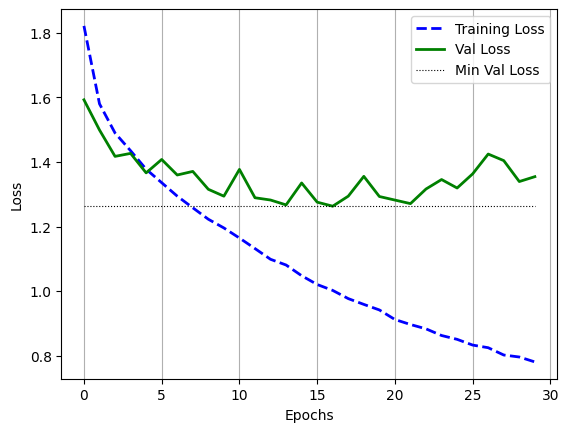

In [ ]:
import matplotlib.pyplot as plt
l = len(history2["val_loss"])
plt.plot(
    range(l), history2["train_loss"], label='Training Loss', linewidth=2.0, color='blue', ls='dashed'
)
plt.plot(
    range(l), history2["val_loss"], label='Val Loss', linewidth=2.0, color='green', ls='solid'
)
plt.plot(
    range(l), [min(history2["val_loss"])]*l, label='Min Val Loss', linewidth=0.8, color='black', ls='dotted'
)
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(axis='x')

In [18]:
from typing import Literal
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def evaluate(y_true, y_pred):
    print(classification_report(y_true, y_pred, digits=4))
    return confusion_matrix(y_true, y_pred)

def format_cm(cm, *, 
              class_names: list[str] | None = None, 
              normalize: bool = False,
              normalize_axis: Literal[0, 1] = 1) -> pd.DataFrame:
    if not class_names:
        class_names = [f"class-{i}" for i in range(len(cm))]
    
    cm_df = pd.DataFrame(cm,
                         index=[f"True: {c}" for c in class_names],
                         columns=[f"Pred: {c}" for c in class_names]
                         )
    if not normalize:
        return cm_df
    
    cm_normalized = cm_df.div(cm_df.sum(axis=normalize_axis), axis= 0 if normalize_axis == 1 else 1)
    cm_normalized = cm_normalized.round(4)
    return cm_normalized

In [19]:
import os

meta = os.path.join(PATH, "batches.meta")

metadata = dutils.read_pkl(meta)
label_name = [l.decode("utf-8") for l in metadata[b'label_names']]

In [21]:
# for net 1
cm = evaluate(y_test_v, y_test_pred)
format_cm(cm, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.7022    0.4550    0.5522      1000
           1     0.6935    0.5340    0.6034      1000
           2     0.4764    0.2930    0.3628      1000
           3     0.3148    0.4200    0.3599      1000
           4     0.4806    0.4340    0.4561      1000
           5     0.4116    0.4260    0.4187      1000
           6     0.5525    0.6260    0.5870      1000
           7     0.5543    0.6070    0.5795      1000
           8     0.6631    0.6160    0.6387      1000
           9     0.4675    0.7190    0.5666      1000

    accuracy                         0.5130     10000
   macro avg     0.5317    0.5130    0.5125     10000
weighted avg     0.5317    0.5130    0.5125     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.455,0.023,0.056,0.054,0.027,0.033,0.020,0.059,0.134,0.139
True: automobile,0.013,0.534,0.005,0.039,0.008,0.021,0.015,0.025,0.042,0.298
True: bird,0.042,0.024,0.293,0.162,0.152,0.101,0.108,0.074,0.015,0.029
True: cat,0.020,0.013,0.047,0.420,0.041,0.201,0.117,0.060,0.024,0.057
True: deer,0.020,0.008,0.091,0.107,0.434,0.064,0.124,0.100,0.022,0.030
True: dog,0.011,0.006,0.037,0.270,0.053,0.426,0.065,0.079,0.028,0.025
True: frog,0.003,0.010,0.047,0.100,0.102,0.062,0.626,0.024,0.007,0.019
True: horse,0.009,0.011,0.024,0.086,0.065,0.093,0.024,0.607,0.012,0.069
True: ship,0.064,0.047,0.008,0.045,0.017,0.021,0.009,0.020,0.616,0.153
True: truck,0.011,0.094,0.007,0.051,0.004,0.013,0.025,0.047,0.029,0.719


In [22]:
y_test_v2 = []
y_test_pred2 = []

net2.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"].to(base_config["base"]["gpu"])
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        logit = net2(_data.reshape((_data.shape[0], -1)))
        loss = criterion(logit, _label)
        
        val_loss += loss
        y_pred = logit.argmax(1)
        
        y_test_v2.extend(_label.cpu().numpy())
        y_test_pred2.extend(y_pred.cpu().numpy())

In [23]:
# for net 2
cm2 = evaluate(y_test_v2, y_test_pred2)
format_cm(cm2, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.5727    0.6340    0.6018      1000
           1     0.6534    0.6900    0.6712      1000
           2     0.5287    0.3410    0.4146      1000
           3     0.4355    0.3310    0.3761      1000
           4     0.5191    0.5160    0.5176      1000
           5     0.5010    0.4800    0.4903      1000
           6     0.5848    0.6550    0.6179      1000
           7     0.6587    0.6330    0.6456      1000
           8     0.5710    0.7720    0.6565      1000
           9     0.5950    0.6230    0.6087      1000

    accuracy                         0.5675     10000
   macro avg     0.5620    0.5675    0.5600     10000
weighted avg     0.5620    0.5675    0.5600     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.634,0.035,0.034,0.011,0.024,0.006,0.019,0.020,0.181,0.036
True: automobile,0.036,0.690,0.007,0.013,0.009,0.012,0.010,0.009,0.090,0.124
True: bird,0.109,0.021,0.341,0.069,0.145,0.089,0.102,0.054,0.039,0.031
True: cat,0.040,0.031,0.064,0.331,0.051,0.190,0.128,0.059,0.053,0.053
True: deer,0.065,0.010,0.069,0.056,0.516,0.046,0.108,0.065,0.041,0.024
True: dog,0.027,0.012,0.042,0.162,0.071,0.480,0.058,0.073,0.043,0.032
True: frog,0.017,0.022,0.042,0.050,0.097,0.044,0.655,0.020,0.027,0.026
True: horse,0.050,0.023,0.029,0.042,0.060,0.067,0.016,0.633,0.020,0.060
True: ship,0.082,0.053,0.007,0.009,0.012,0.011,0.009,0.007,0.772,0.038
True: truck,0.047,0.159,0.010,0.017,0.009,0.013,0.015,0.021,0.086,0.623


In [24]:
test_df.head(2)

label,data,label_names
i64,"array[u8, 3072]",str
3,"[158, 159, … 110]","""cat"""
8,"[235, 231, … 199]","""ship"""


In [36]:
def shift_data(val: list[int]):
    shift = 4
    size = 32
    
    new_data = []
    for i in range(0, len(val), size):
        new_data.extend((([0] * shift) + val[i : i + size])[:size])
    return new_data

In [58]:
test_df_shifted = test_df.with_columns(pl.Series("data",[shift_data(data_list) for data_list in test_df["data"].to_list()] )) 

In [59]:
test_shifted_dataset = dutils.CIFARData(test_df_shifted)
test_shifted_loader = DataLoader(test_shifted_dataset, 
                       batch_size=base_config["neural"]["batch_size"], num_workers=2)

In [62]:
test_df_shifted.head(2)

label,data,label_names
i64,list[i64],str
3,"[0, 0, … 175]","""cat"""
8,"[0, 0, … 153]","""ship"""


In [60]:
y_test_v_shifted = []
y_test_pred_shifted = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(test_shifted_loader, 1):
        _data = batch["data"].to(base_config["base"]["gpu"])
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        logit = net(_data.reshape((_data.shape[0], -1)))
        loss = criterion(logit, _label)
        
        val_loss += loss
        y_pred = logit.argmax(1)
        
        y_test_v_shifted.extend(_label.cpu().numpy())
        y_test_pred_shifted.extend(y_pred.cpu().numpy())

In [61]:
y_test_v_shifted2 = []
y_test_pred_shifted2 = []

net2.eval()
with torch.no_grad():
    for step, batch in enumerate(test_shifted_loader, 1):
        _data = batch["data"].to(base_config["base"]["gpu"])
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        logit = net2(_data.reshape((_data.shape[0], -1)))
        loss = criterion(logit, _label)
        
        val_loss += loss
        y_pred = logit.argmax(1)
        
        y_test_v_shifted2.extend(_label.cpu().numpy())
        y_test_pred_shifted2.extend(y_pred.cpu().numpy())

In [63]:
# for net 1
cm_shifted = evaluate(y_test_v_shifted, y_test_pred_shifted)
format_cm(cm_shifted, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.6919    0.1190    0.2031      1000
           1     0.6678    0.1990    0.3066      1000
           2     0.3110    0.0880    0.1372      1000
           3     0.2188    0.3980    0.2824      1000
           4     0.4252    0.1820    0.2549      1000
           5     0.1905    0.6160    0.2910      1000
           6     0.4261    0.4240    0.4251      1000
           7     0.4464    0.3080    0.3645      1000
           8     0.5422    0.2700    0.3605      1000
           9     0.3575    0.5660    0.4383      1000

    accuracy                         0.3170     10000
   macro avg     0.4277    0.3170    0.3063     10000
weighted avg     0.4277    0.3170    0.3063     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.119,0.012,0.056,0.134,0.010,0.311,0.018,0.067,0.098,0.175
True: automobile,0.007,0.199,0.027,0.099,0.008,0.189,0.034,0.065,0.031,0.341
True: bird,0.013,0.003,0.088,0.201,0.083,0.391,0.141,0.030,0.014,0.036
True: cat,0.002,0.005,0.012,0.398,0.015,0.426,0.064,0.029,0.013,0.036
True: deer,0.005,0.004,0.046,0.182,0.182,0.308,0.194,0.033,0.014,0.032
True: dog,0.001,0.001,0.011,0.255,0.012,0.616,0.051,0.025,0.014,0.014
True: frog,0.000,0.002,0.011,0.222,0.048,0.252,0.424,0.019,0.001,0.021
True: horse,0.004,0.001,0.017,0.158,0.051,0.361,0.040,0.308,0.009,0.051
True: ship,0.018,0.031,0.008,0.084,0.011,0.224,0.011,0.032,0.270,0.311
True: truck,0.003,0.040,0.007,0.086,0.008,0.156,0.018,0.082,0.034,0.566


In [64]:
# for net 2
cm_shifted2 = evaluate(y_test_v_shifted2, y_test_pred_shifted2)
format_cm(cm_shifted2, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.6402    0.1050    0.1804      1000
           1     0.6702    0.2500    0.3642      1000
           2     0.2952    0.1290    0.1795      1000
           3     0.1894    0.4610    0.2685      1000
           4     0.3964    0.3080    0.3467      1000
           5     0.2820    0.4540    0.3479      1000
           6     0.5622    0.2710    0.3657      1000
           7     0.3979    0.3390    0.3661      1000
           8     0.4558    0.3200    0.3760      1000
           9     0.3209    0.6960    0.4393      1000

    accuracy                         0.3333     10000
   macro avg     0.4210    0.3333    0.3234     10000
weighted avg     0.4210    0.3333    0.3234     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.105,0.019,0.055,0.173,0.019,0.056,0.011,0.109,0.215,0.238
True: automobile,0.006,0.250,0.035,0.069,0.012,0.074,0.012,0.043,0.057,0.442
True: bird,0.008,0.010,0.129,0.342,0.138,0.142,0.061,0.084,0.029,0.057
True: cat,0.002,0.007,0.040,0.461,0.039,0.285,0.029,0.058,0.013,0.066
True: deer,0.005,0.006,0.052,0.326,0.308,0.117,0.062,0.042,0.016,0.066
True: dog,0.004,0.001,0.031,0.334,0.033,0.454,0.022,0.063,0.015,0.043
True: frog,0.000,0.000,0.037,0.310,0.120,0.177,0.271,0.019,0.002,0.064
True: horse,0.007,0.006,0.027,0.236,0.068,0.185,0.007,0.339,0.010,0.115
True: ship,0.018,0.031,0.008,0.116,0.028,0.051,0.002,0.044,0.320,0.382
True: truck,0.009,0.043,0.023,0.067,0.012,0.069,0.005,0.051,0.025,0.696


In [65]:
torch.save(net.state_dict(), "../artifacts/neural_model1_v01.pth")
torch.save(net2.state_dict(), "../artifacts/neural_model2_v01.pth")

In [66]:
y_train_v = []
y_train_pred = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(train_loader, 1):
        _data = batch["data"].to(base_config["base"]["gpu"])
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        logit = net(_data.reshape((_data.shape[0], -1)))
        loss = criterion(logit, _label)
        
        val_loss += loss
        y_pred = logit.argmax(1)
        
        y_train_v.extend(_label.cpu().numpy())
        y_train_pred.extend(y_pred.cpu().numpy())

In [67]:
cm_train = evaluate(y_train_v, y_train_pred)
format_cm(cm_train, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.7453    0.4843    0.5871      4000
           1     0.7476    0.6028    0.6674      4000
           2     0.5610    0.3543    0.4343      4000
           3     0.3692    0.4850    0.4193      4000
           4     0.5258    0.4995    0.5123      4000
           5     0.4538    0.4773    0.4652      4000
           6     0.5973    0.6545    0.6246      4000
           7     0.6319    0.6685    0.6497      4000
           8     0.7094    0.6690    0.6886      4000
           9     0.5232    0.7850    0.6279      4000

    accuracy                         0.5680     40000
   macro avg     0.5864    0.5680    0.5676     40000
weighted avg     0.5864    0.5680    0.5676     40000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.4842,0.0345,0.0542,0.0542,0.0308,0.0270,0.0177,0.0500,0.1048,0.1425
True: automobile,0.0132,0.6028,0.0075,0.0290,0.0075,0.0100,0.0190,0.0170,0.0390,0.2550
True: bird,0.0340,0.0100,0.3542,0.1352,0.1550,0.1050,0.0990,0.0595,0.0177,0.0302
True: cat,0.0125,0.0135,0.0385,0.4850,0.0322,0.2018,0.0992,0.0462,0.0268,0.0442
True: deer,0.0232,0.0072,0.0725,0.1050,0.4995,0.0545,0.1055,0.0828,0.0217,0.0280
True: dog,0.0040,0.0088,0.0330,0.2630,0.0508,0.4772,0.0555,0.0660,0.0210,0.0208
True: frog,0.0050,0.0098,0.0355,0.1005,0.0880,0.0630,0.6545,0.0213,0.0062,0.0162
True: horse,0.0072,0.0095,0.0195,0.0798,0.0660,0.0798,0.0170,0.6685,0.0110,0.0418
True: ship,0.0580,0.0385,0.0110,0.0368,0.0155,0.0140,0.0102,0.0102,0.6690,0.1368
True: truck,0.0082,0.0718,0.0055,0.0250,0.0048,0.0195,0.0180,0.0365,0.0258,0.7850


In [68]:
train_df_shifted = train_df.with_columns(pl.Series("data",[shift_data(data_list) for data_list in train_df["data"].to_list()] )) 

train_shifted_dataset = dutils.CIFARData(train_df_shifted)
train_shifted_loader = DataLoader(train_shifted_dataset, 
                       batch_size=base_config["neural"]["batch_size"], num_workers=2)

In [69]:
y_train_shifted = []
y_train_pred_shifted = []

net.eval()
with torch.no_grad():
    for step, batch in enumerate(train_shifted_loader, 1):
        _data = batch["data"].to(base_config["base"]["gpu"])
        _label = batch["label"].to(base_config["base"]["gpu"]).reshape((-1))
        logit = net(_data.reshape((_data.shape[0], -1)))
        loss = criterion(logit, _label)
        
        val_loss += loss
        y_pred = logit.argmax(1)
        
        y_train_shifted.extend(_label.cpu().numpy())
        y_train_pred_shifted.extend(y_pred.cpu().numpy())

In [70]:
cm_train_shifted = evaluate(y_train_shifted, y_train_pred_shifted)
format_cm(cm_train_shifted, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.7169    0.1165    0.2004      4000
           1     0.6772    0.2150    0.3264      4000
           2     0.3145    0.0932    0.1438      4000
           3     0.2172    0.4047    0.2827      4000
           4     0.4274    0.2023    0.2746      4000
           5     0.1829    0.5840    0.2785      4000
           6     0.4223    0.4073    0.4147      4000
           7     0.4177    0.2850    0.3388      4000
           8     0.5485    0.2797    0.3705      4000
           9     0.3638    0.5590    0.4407      4000

    accuracy                         0.3147     40000
   macro avg     0.4288    0.3147    0.3071     40000
weighted avg     0.4288    0.3147    0.3071     40000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.1165,0.0168,0.0503,0.1270,0.0120,0.3115,0.0180,0.0788,0.0992,0.1700
True: automobile,0.0060,0.2150,0.0215,0.1128,0.0148,0.1608,0.0288,0.0703,0.0365,0.3338
True: bird,0.0068,0.0045,0.0932,0.1882,0.0670,0.4265,0.1390,0.0332,0.0115,0.0300
True: cat,0.0018,0.0050,0.0177,0.4048,0.0125,0.4182,0.0748,0.0232,0.0127,0.0292
True: deer,0.0035,0.0030,0.0370,0.1818,0.2023,0.3113,0.1815,0.0398,0.0125,0.0275
True: dog,0.0020,0.0032,0.0152,0.2718,0.0190,0.5840,0.0535,0.0265,0.0120,0.0127
True: frog,0.0015,0.0025,0.0200,0.2302,0.0508,0.2535,0.4072,0.0132,0.0018,0.0192
True: horse,0.0028,0.0068,0.0150,0.1630,0.0802,0.3580,0.0342,0.2850,0.0110,0.0440
True: ship,0.0180,0.0288,0.0135,0.0995,0.0050,0.2092,0.0082,0.0268,0.2798,0.3113
True: truck,0.0038,0.0320,0.0130,0.0845,0.0098,0.1605,0.0190,0.0855,0.0330,0.5590


In [79]:
# no of parameters
total_trainable_param = 0
for param in net.parameters():
    if param.requires_grad:
        if len(param.shape) == 2:
            total_trainable_param += param.shape[0] * param.shape[1]
        elif len(param.shape) == 1:
            total_trainable_param += param.shape[0]
        else:
            print("Unknown shape")
            print(param)

In [80]:
print("Number to total trainable parameters: ",total_trainable_param)

Number to total trainable parameters:  2106890
